In [1]:
import numpy as np
from astropy.io import fits
import matplotlib.pyplot as plt
import matplotlib.patches as patches
#import cv2
from skimage.measure import profile_line
from matplotlib.ticker import (MultipleLocator, AutoMinorLocator)
from pathlib import Path
from datetime import datetime
import matplotlib.dates as mdates ## Import required library
import sys
from scipy.optimize import curve_fit
sys.path.append('/Users/coletamburri/Desktop/Flare_Patrol_Analysis/WORKING_SOURCE/')
import dkistpkg_ct as DKISTanalysis

# Gaussian + linear background
def gaussian_linear(x, A, mu, sigma, B, C):
    return A * np.exp(-(x - mu)**2 / (2 * sigma**2)) + B*x + C

In [2]:
# get times and Fried parameter for entire series
vbi_filenames=[]

path = '/Volumes/ViSP_External/pid_2_11_VBI/MBVIDS'
# Specify the directory
folder = Path(path)

# List all files and folders
for item in folder.iterdir():
    if item.is_file():
        
        vbi_filenames.append(item.name)

vbi_filenames.sort()


In [3]:
del vbi_filenames[0:3]
vbi_filenames

['VBI_2024_08_11T22_23_34_333333_00656282_I_MBVIDS_L1.fits',
 'VBI_2024_08_11T22_23_37_000000_00656282_I_MBVIDS_L1.fits',
 'VBI_2024_08_11T22_23_39_666666_00656282_I_MBVIDS_L1.fits',
 'VBI_2024_08_11T22_23_42_333333_00656282_I_MBVIDS_L1.fits',
 'VBI_2024_08_11T22_23_45_000000_00656282_I_MBVIDS_L1.fits',
 'VBI_2024_08_11T22_23_47_666666_00656282_I_MBVIDS_L1.fits',
 'VBI_2024_08_11T22_23_50_333333_00656282_I_MBVIDS_L1.fits',
 'VBI_2024_08_11T22_23_53_000000_00656282_I_MBVIDS_L1.fits',
 'VBI_2024_08_11T22_23_55_666666_00656282_I_MBVIDS_L1.fits',
 'VBI_2024_08_11T22_23_58_333333_00656282_I_MBVIDS_L1.fits',
 'VBI_2024_08_11T22_24_01_000000_00656282_I_MBVIDS_L1.fits',
 'VBI_2024_08_11T22_24_03_666666_00656282_I_MBVIDS_L1.fits',
 'VBI_2024_08_11T22_24_06_333333_00656282_I_MBVIDS_L1.fits',
 'VBI_2024_08_11T22_24_09_000000_00656282_I_MBVIDS_L1.fits',
 'VBI_2024_08_11T22_24_11_666666_00656282_I_MBVIDS_L1.fits',
 'VBI_2024_08_11T22_24_14_333333_00656282_I_MBVIDS_L1.fits',
 'VBI_2024_08_11T22_24_1

In [4]:
samp = fits.open(path+'/'+vbi_filenames[0])[1].header
samp

SIMPLE  =                    T                                                  
BITPIX  =                  -32 / array data type                                
NAXIS   =                    3 / number of array dimensions                     
NAXIS1  =                 4096                                                  
NAXIS2  =                 4096                                                  
NAXIS3  =                    1                                                  
EXTNAME = 'observation'        / name of this binary table extension            
BUNIT   = 'ct      '                                                            
DATE    = '2025-07-09T00:33:45.095'                                             
DATE-BEG= '2024-08-11T22:23:34.333333'                                          
DATE-END= '2024-08-11T22:23:34.334338'                                          
TELAPSE = 0.001005199737846851 / [s]                                            
DATE-AVG= '2024-08-11T22:23:

In [5]:
#this file contains the coordinates of the ViSP pixels in VBI space BEFORE the recalibration in March 2026; 
# do not trust third array (actual values); first two should be OK
visp_file = '/Users/coletamburri/Desktop/DKIST_August2024_Flare_RefResponse_FirstDraft/ViSP_coalign_result_11Aug_Cclass'
X2=np.load(visp_file)['arr_0']
Y2=np.load(visp_file)['arr_1']
V=np.load(visp_file)['arr_2']

In [6]:
# and this file contains the coordinates in the ViSP space for arms1 and 2
# redid the co-alignment for the new data processed March 2026
#dkist_coord_file = '/Users/coletamburri/Desktop/11_Aug_2024_Cclass_Flare/Processed_ViSP_VBI_11Aug2024/ViSPcoords.npz' ## old coordinates
dkist_coord_file = '/Users/coletamburri/Desktop/DKIST_August2024_Flare_RefResponse_FirstDraft/ViSPcoords_newcalib.npz' ## new coordinates
dkist_coords = np.load(dkist_coord_file)

xarr_CaII = dkist_coords['xarr_caII']
yarr_CaII = dkist_coords['yarr_caII']

xarr_hbeta = dkist_coords['xarr_hbeta']
yarr_hbeta = dkist_coords['yarr_hbeta']

In [7]:
desired_y = [-240,-243,-246]
desired_ystr = ['–240','–243','–246']

desired_x = [760,763,766]
desired_xstr = ['760','763','766']

In [8]:
xlow = 1800
xhigh = 2300
ylow = 2000
yhigh = 2500

vbiy=[]
for i in range(len(desired_y)):
    indch = DKISTanalysis.find_nearest(yarr_CaII,desired_y[i])[1]
    vbiy.append(int(Y2[indch][0])-ylow)

vbix=[]
for i in range(len(desired_x)):
    indch = DKISTanalysis.find_nearest(xarr_CaII,desired_x[i])[1]
    vbix.append(int(X2[0][indch])-xlow)

In [9]:
timesvbi=[]
friedvbi=[]

for i in range(len(vbi_filenames)-1):
    timesvbi.append(fits.open(path+'/'+vbi_filenames[i])[1].header['DATE-BEG'])
    if fits.open(path+'/'+vbi_filenames[i])[1].header['AO_LOCK']==True:
        friedvbi.append(fits.open(path+'/'+vbi_filenames[i])[1].header['ATMOS_R0']*100)    
    else:
        friedvbi.append(float(0))

In [10]:
#convert to datetime
datetimevbi=[]
for i in range(len(timesvbi)):
    date_str = timesvbi[i]
    # Format: Year-Month-Day Hour:Minute:Second
    datetimevbi.append(datetime.strptime(date_str, "%Y-%m-%dT%H:%M:%S.%f"))

In [11]:
#strip day
onlytimevbi = []
for i in range(len(timesvbi)):
    date_str = timesvbi[i]
    # Format: Year-Month-Day Hour:Minute:Second
    onlytimevbi.append(date_str[-15:-7])

In [12]:
file = '/Volumes/ViSP_External/postdestretch_dataCube_Halpha_C_class_impulsive_phase_Halpha_177_347.fits'

In [13]:
destretch = fits.open(file)

In [14]:
destretch

In [15]:
np.shape(destretch[0].data)

(170, 4095, 4095)

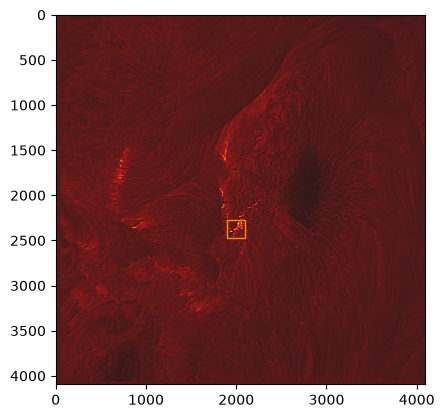

In [16]:
import sunpy.visualization.colormaps as cm
import matplotlib
fig,ax=plt.subplots()
from matplotlib.patches import Rectangle
sdoaia304 = matplotlib.colormaps['sdoaia304']
im=ax.pcolormesh(destretch[0].data[100,:,:]/1e4,cmap=sdoaia304,alpha=0.9)
#add smaller bounding box for other figure
xlow2 = 1900#had to shift manually by 20 pixels to the right for some reason
xhigh2 = 2100#had to shift manually by 20 pixels to the right for some reason
ylow2 = 2270
yhigh2 = 2470

box2 = Rectangle((xlow2, ylow2), width=xhigh2-xlow2, height=yhigh2-ylow2, edgecolor='darkorange', facecolor='none', linewidth=1,linestyle='solid')

# 3. Add the box patch to the axes
ax.add_patch(box2)
ax.set_aspect('equal')
ax.invert_yaxis()


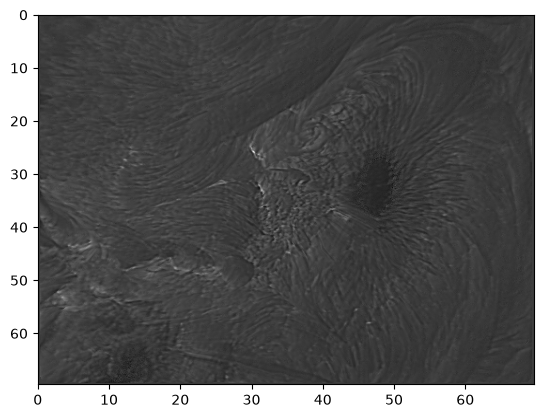

In [24]:
i=0
slices=[20, 23, 27, 32, 35, 38, 41, 45, 50, 60, 105, 110]

X=np.arange(np.shape(destretch[0].data[slices[i],:,:])[0])*0.017
Y=np.arange(np.shape(destretch[0].data[slices[i],:,:])[0])*0.017
fig,ax=plt.subplots()
ax.pcolormesh(X,Y,destretch[0].data[slices[i],:,:],cmap='grey')
ax.invert_yaxis()

In [25]:
vbix

[13, 208, 410]

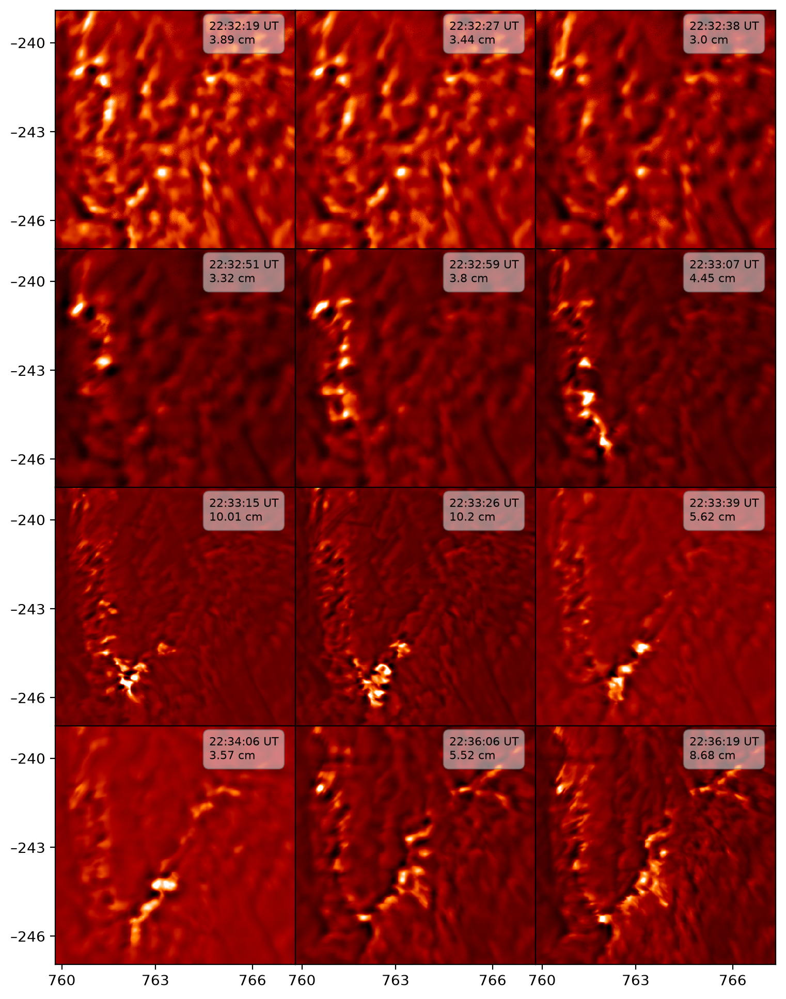

In [26]:
# X=np.arange(np.shape(destretch[0].data[slices[i],:,:])[0])#*0.017
# Y=np.arange(np.shape(destretch[0].data[slices[i],:,:])[0])#*0.017
    
fig,ax=plt.subplots(4,3,dpi=200,figsize=(9,12))
for i in range(len(slices)):
    #ax.flatten()[i].pcolormesh(X,Y,destretch[0].data[slices[i],:,:],cmap='grey')
    choice =destretch[0].data[slices[i],ylow:yhigh,xlow:xhigh]
    normalized = (choice-choice.min()) /(choice.max() -choice.min())
    if i==0 or i==1 or i==2 or i==9 or i==10 or i==11:
        ax.flatten()[i].pcolormesh(normalized,cmap='sdoaia304',vmin=0,vmax=0.85)
    else:
        ax.flatten()[i].pcolormesh(normalized,cmap='sdoaia304',vmin=0.05,vmax=0.75)
    ax.flatten()[i].invert_yaxis()
    if i==1 or i==2 or i== 4 or i==5 or i == 7 or i==8:
        ax.flatten()[i].set_xticks([])
        ax.flatten()[i].set_yticks([])
    if i == 0 or i==3 or i==6 or i == 9:
        ax.flatten()[i].set_xticks([])
        ax.flatten()[i].set_yticks(vbiy,desired_ystr,fontsize=10)
    if i>9:
        ax.flatten()[i].set_yticks([])
    if i>8:
        ax.flatten()[i].set_xticks(vbix,desired_xstr,fontsize=10) 
    # ax.flatten()[i].set_xlim([X[1800],X[2300]])
    # ax.flatten()[i].set_ylim([Y[2500],Y[2000]])
    # rect = patches.Rectangle((Y[2110], X[2125]), Y[90], X[30], 
    #                      linewidth=2, 
    #                      edgecolor='r',
    #                      facecolor='none')
    # ax.flatten()[i].add_patch(rect)
    # rect = patches.Rectangle((Y[1900], X[2270]), Y[200], X[200],
    #                      linewidth=2, 
    #                      edgecolor='r', 
    #                      facecolor='none')
    # ax.flatten()[i].add_patch(rect)

    # Define the text with a newline
    textstr = onlytimevbi[177+slices[i]]+' UT\n'+str(round(friedvbi[177+slices[i]],2))+' cm'
    
    # Add text with transparent background
    ax.flatten()[i].text(0.64, 0.86, textstr, 
            fontsize=8, 
        bbox=dict(facecolor='white', alpha=0.5, edgecolor='gray', boxstyle='round,pad=0.5'),transform=ax.flatten()[i].transAxes)

fig.subplots_adjust(wspace=0, hspace=0)

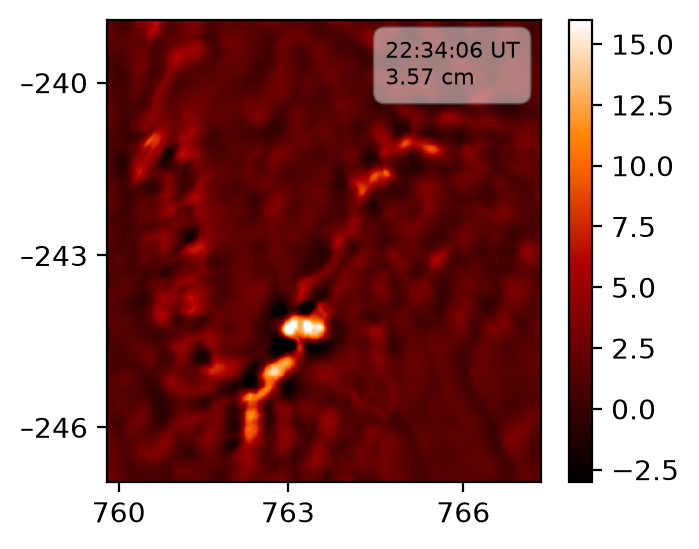

In [93]:
# X=np.arange(np.shape(destretch[0].data[slices[i],:,:])[0])#*0.017
# Y=np.arange(np.shape(destretch[0].data[slices[i],:,:])[0])#*0.017
i=9
fig,ax=plt.subplots(dpi=200,figsize=(3.5,3))
choice =destretch[0].data[slices[i],ylow:yhigh,xlow:xhigh]
normalized = (choice-choice.min()) /(choice.max() -choice.min())
if i==0 or i==1 or i==2 or i==9 or i==10 or i==11:
    im = ax.pcolormesh(choice/1e4,cmap='sdoaia304',vmin=-3,vmax=16)
else:
    im = ax.pcolormesh(choice/1e4,cmap='sdoaia304',vmin=-3,vmax=16)
ax.invert_yaxis()

if i == 0 or i==3 or i==6 or i == 9:
    ax.set_xticks([])
    ax.set_yticks(vbiy,desired_ystr,fontsize=10)
if i>9:
    ax.set_yticks([])
if i>8:
    ax.set_xticks(vbix,desired_xstr,fontsize=10) 
# ax.flatten()[i].set_xlim([X[1800],X[2300]])
# ax.flatten()[i].set_ylim([Y[2500],Y[2000]])
# rect = patches.Rectangle((Y[2110], X[2125]), Y[90], X[30], 
#                      linewidth=2, 
#                      edgecolor='r',
#                      facecolor='none')
# ax.flatten()[i].add_patch(rect)
# rect = patches.Rectangle((Y[1900], X[2270]), Y[200], X[200],
#                      linewidth=2, 
#                      edgecolor='r', 
#                      facecolor='none')
# ax.flatten()[i].add_patch(rect)

# Define the text with a newline
textstr = onlytimevbi[177+slices[i]]+' UT\n'+str(round(friedvbi[177+slices[i]],2))+' cm'

# Add text with transparent background
ax.text(0.64, 0.86, textstr, 
        fontsize=8,bbox=dict(facecolor='white', alpha=0.5, edgecolor='gray', boxstyle='round,pad=0.5'),transform=ax.transAxes)
fig.colorbar(im)
fig.subplots_adjust(wspace=0, hspace=0)

In [94]:
sel=destretch[0].data[slices3[i],2270:2470,1900:2100]


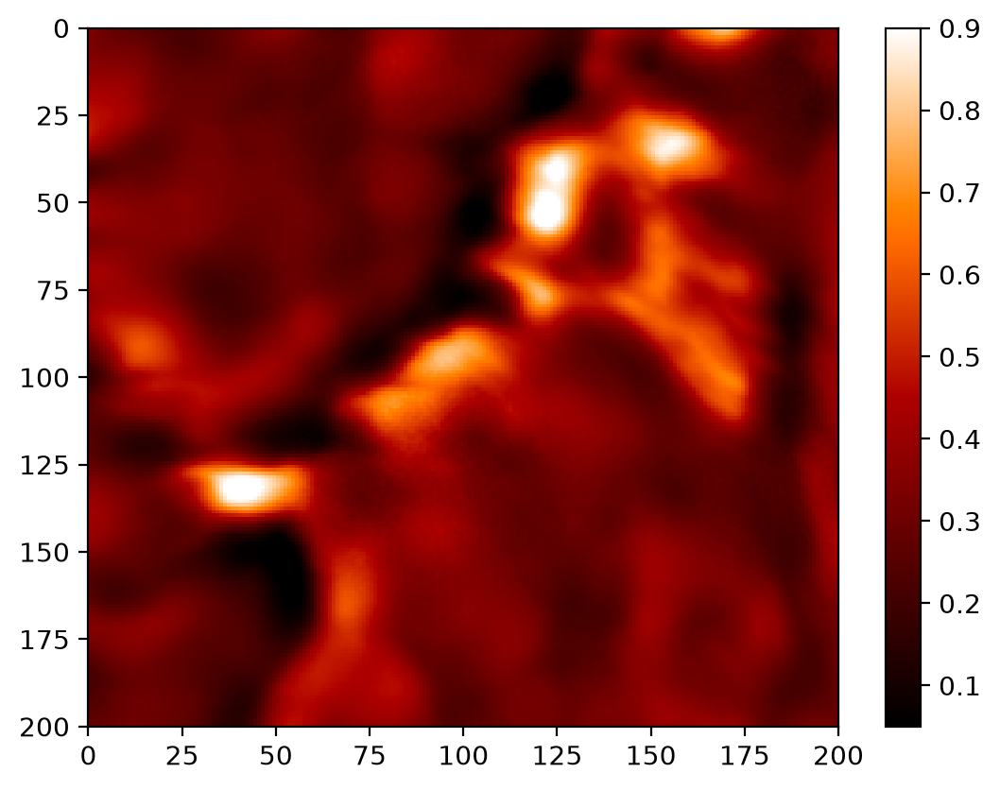

In [95]:
fig,ax=plt.subplots(dpi=200)
choice =destretch[0].data[slices2[15],2270:2470,1900:2100]
normalized = (choice-choice.min()) /(choice.max() -choice.min())
im=ax.pcolormesh(normalized,cmap='sdoaia304',vmin=0.05,vmax=0.9)
ax.invert_yaxis()
fig.colorbar(im)

In [96]:
np.shape(destretch[0].data[slices2[15],:,:])

(4095, 4095)

In [97]:
slices2[15]


np.int64(105)

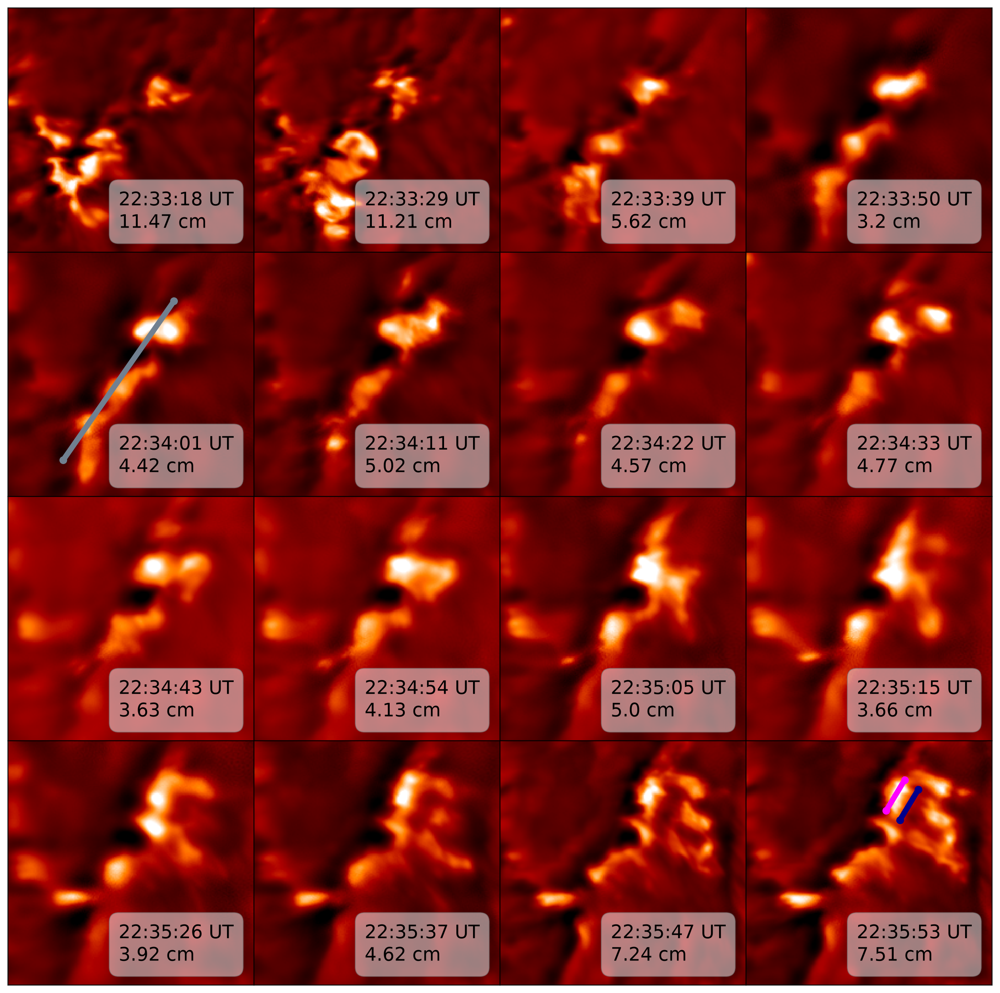

In [100]:
slicespre=np.arange(42,100,4)
slices2 = np.append(slicespre,100)
fig,ax=plt.subplots(4,4,dpi=200,figsize=(16,16))
for i in range(len(slices2)):
    #ax.flatten()[i].pcolormesh(X,Y,destretch[0].data[slices[i],:,:],cmap='grey')
    choice =destretch[0].data[slices2[i],2270:2470,1900:2100]
    normalized = (choice-choice.min()) /(choice.max() -choice.min())
    # if i==0 or i==1 or i==2 or i==9 or i==10 or i==11:
    #     ax.flatten()[i].pcolormesh(normalized,cmap='sdoaia304',vmin=0,vmax=0.85)
    # else:
    #     ax.flatten()[i].pcolormesh(normalized,cmap='sdoaia304',vmin=0.05,vmax=0.75)
    ax.flatten()[i].pcolormesh(normalized,cmap='sdoaia304',vmin=0.05,vmax=0.9)
    ax.flatten()[i].invert_yaxis()
    ax.flatten()[i].set_xticks([])
    ax.flatten()[i].set_yticks([])
    
    # ax.flatten()[i].set_xlim([X[1800],X[2300]])
    # ax.flatten()[i].set_ylim([Y[2500],Y[2000]])
    # rect = patches.Rectangle((Y[2110], X[2125]), Y[90], X[30], 
    #                      linewidth=2, 
    #                      edgecolor='r',
    #                      facecolor='none')
    # ax.flatten()[i].add_patch(rect)
    # rect = patches.Rectangle((Y[1900], X[2270]), Y[200], X[200],
    #                      linewidth=2, 
    #                      edgecolor='r', 
    #                      facecolor='none')
    # ax.flatten()[i].add_patch(rect)

    # Define the text with a newline
    textstr = onlytimevbi[177+slices2[i]]+' UT\n'+str(round(friedvbi[177+slices2[i]],2))+' cm'
    
    # Add text with transparent background
    ax.flatten()[i].text(0.45, 0.1, textstr, 
            fontsize=17, 
        bbox=dict(facecolor='white', alpha=0.5, edgecolor='gray', boxstyle='round,pad=0.5'),transform=ax.flatten()[i].transAxes)

fig.subplots_adjust(wspace=0, hspace=0)

# plot first cut
x=np.arange(50,150,1)
y=[]
for i in x:
    y.append(np.where(sel[:,i]==np.max(sel[:,i]))[0][0])

spatial_samp=0.017
# two points
x0, y0 = 45,170
x1, y1 = 135,40
i=4
sel=destretch[0].data[slices2[i],2270:2470,1900:2100]

profile1 = profile_line(sel,[y0,x0],[y1,x1])  # note: row,col order

xdirection1 = np.arange(len(profile1))*spatial_samp


ax.flatten()[i].plot([x0, x1], [y0, y1], 'o-',linewidth=5,color='slategray')


# two points
x0, y0 = 2025-1900,2335-2270
x1, y1 = 2040-1900,2310-2270

x2, y2 = 2014-1900,2327-2270
x3, y3 = 2029-1900,2302-2270

profile2 = profile_line(sel,[y0,x0],[y1,x1])  # note: row,col order
profile3 = profile_line(sel,[y2,x2],[y3,x3])  # note: row,col order


xdirection2 = np.arange(len(profile2))*spatial_samp
xdirection3 = np.arange(len(profile3))*spatial_samp

ax.flatten()[-1].plot([x0, x1], [y0, y1], 'o-',linewidth=5,color='darkblue')
ax.flatten()[-1].plot([x2, x3], [y2, y3], 'o-',linewidth=5,color='magenta')




In [99]:
x0, y0 = 2025-1900,2335-2270
x1, y1 = 2040-1900,2310-2270

In [46]:
np.sqrt((y1-y0)**2+(x1-x0)**2)

np.float64(29.154759474226502)

In [47]:
xdirection2[-1]/0.017

np.float64(30.0)

fwhm2: 301.7861197068444 km
err2: 8.41879336858316 km
fwhm2: 468.98296821250875 km
err2: 23.11704144592306 km
fwhm2: 342.9351731647394 km
err2: 22.11051501050014 km


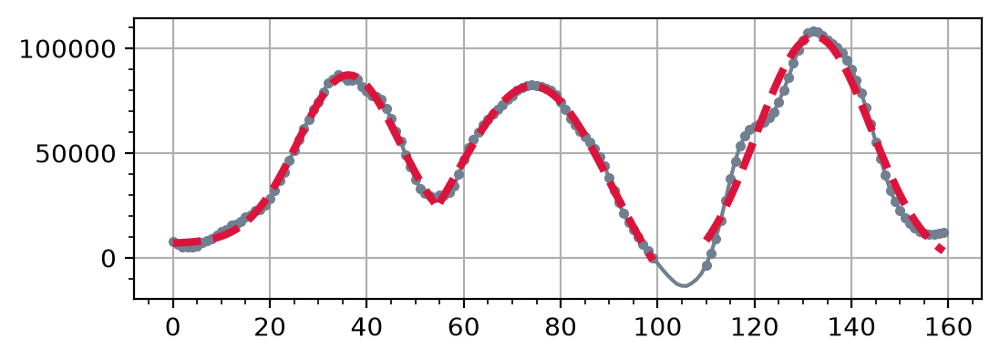

In [70]:


sel=destretch[0].data[slices3[i],2270:2470,1900:2100]
inds = [0,55,55,100,110,160]
# plot
fig,ax=plt.subplots(dpi=200,figsize=(6,2))
ax.plot(xdirection1/0.017, profile1,c='slategray')

x = xdirection1[inds[0]:inds[1]]/0.017
y = profile1[inds[0]:inds[1]]

# Initial guesses
initial_guess = [np.max(y)-np.min(y), np.mean(x), 10, 0, np.min(y)]


params, cov = curve_fit(gaussian_linear, x, y, p0=initial_guess)
err = np.sqrt(np.diag(cov))[2]

A, mu, sigma, B, C = params
print("fwhm2:", sigma*2.3548*0.017*727,'km')
print("err2:", err*2.3548*0.017*727,'km')

# Plot
ax.plot(x, y, '.', label='Data',c='slategray')
ax.plot(x, gaussian_linear(x, *params), '--', color='crimson',linewidth=3, label='Fit')


# x = positions
x = xdirection1[inds[2]:inds[3]]/0.017
y = profile1[inds[2]:inds[3]]

# Initial guesses
initial_guess = [np.max(y)-np.min(y), np.mean(x), 10, 0, np.min(y)]

params, cov = curve_fit(gaussian_linear, x, y, p0=initial_guess)
err = np.sqrt(np.diag(cov))[2]

A, mu, sigma, B, C = params
print("fwhm2:", sigma*2.3548*0.017*727,'km')
print("err2:", err*2.3548*0.017*727,'km')

# Plot
ax.plot(x, y, '.', label='Data',c='slategray')
ax.plot(x, gaussian_linear(x, *params), '--', color='crimson',linewidth=3, label='Fit')

# x = positions
x = xdirection1[inds[4]:inds[5]]/0.017
y = profile1[inds[4]:inds[5]]

# Initial guesses
initial_guess = [np.max(y)-np.min(y), np.mean(x), 10, 0, np.min(y)]

params, cov = curve_fit(gaussian_linear, x, y, p0=initial_guess)

err = np.sqrt(np.diag(cov))[2]

A, mu, sigma, B, C = params
print("fwhm2:", sigma*2.3548*0.017*727,'km')
print("err2:", err*2.3548*0.017*727,'km')

# Plot
ax.plot(x, y, '.', label='Data',c='slategray')
ax.plot(x, gaussian_linear(x, *params), '--', color='crimson',linewidth=3, label='Fit')


ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())
ax.grid()


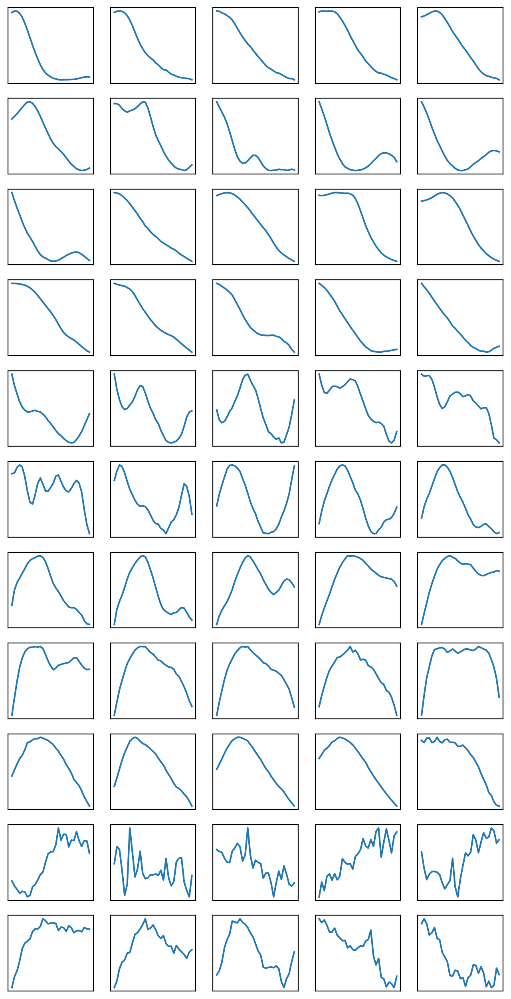

In [71]:
slices3 = np.arange(50,160,2)

allslices = []

colors = plt.cm.turbo(np.linspace(0,1,len(slices3)))
fig,ax=plt.subplots(11,5,dpi=200,figsize=(8,16));

for i in range(len(slices3)):
    sel=destretch[0].data[slices3[i],2270:2470,1900:2100]

    profile = profile_line(sel,[y0,x0],[y1,x1])
    allslices.append(profile)
    ax.flatten()[i].plot(profile)
    ax.flatten()[i].set_xticks([])
    ax.flatten()[i].set_yticks([])


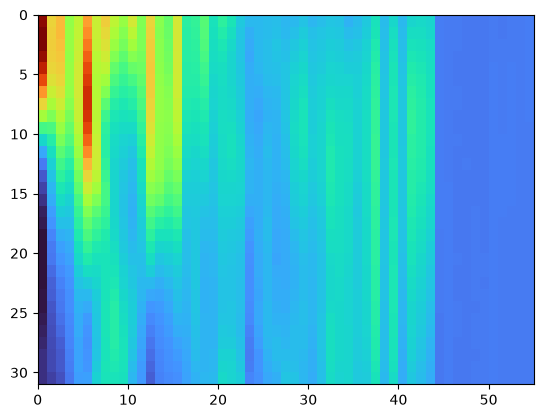

In [72]:
fig,ax=plt.subplots()
ax.pcolormesh(np.transpose(allslices),cmap='turbo')
ax.invert_yaxis()

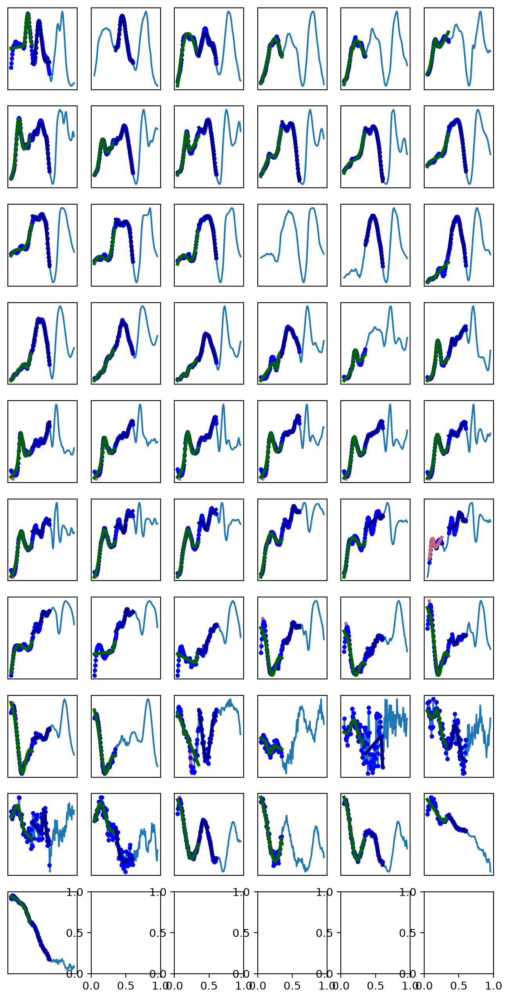

In [73]:
# time evolution of peaks
spatial_samp = 0.017
ysp0=[]
ysp1 = []
ysp2 = []

ysperr0=[]
ysperr1 = []
ysperr2 = []
x0, y0 = 50,170
x1, y1 = 145,40

fig,ax=plt.subplots(10,6,dpi=200,figsize=(8,16));
for i in range(len(slices3)):
    sel=destretch[0].data[slices3[i],2270:2470,1900:2100]

    profile = profile_line(sel,[y0,x0],[y1,x1])  # note: row,col order

    ax.flatten()[i].plot(profile)
    ax.flatten()[i].set_xticks([])
    ax.flatten()[i].set_yticks([])


    xdirection = np.arange(len(profile))*spatial_samp

    # number 0
    # x = positions
    x = xdirection[5:38]/0.017
    y = profile[5:38]
    
    # Initial guesses
    initial_guess = [np.max(y)-np.min(y), np.mean(x), 10, 0, np.min(y)]

    try:
        params, cov = curve_fit(gaussian_linear, x, y, p0=initial_guess)
    except RuntimeError: 
        ysp0.append(0)
        ysperr0.append(0)
    else:
        A, mu, sigma, B, C = params
        ysp0.append(mu)
        ysperr0.append(np.sqrt(np.abs(cov[1,1])))
        ax.flatten()[i].plot(x, y, 'b.', label='Data')
        ax.flatten()[i].plot(x, gaussian_linear(x, *params), '-', color='#CC6677',linewidth=3, label='Fit')

    # number 1
    # x = positions
    x = xdirection[inds[0]:inds[1]]/0.017
    y = profile[inds[0]:inds[1]]
    
    # Initial guesses
    initial_guess = [np.max(y)-np.min(y), np.mean(x), 10, 0, np.min(y)]

    try:
        params, cov = curve_fit(gaussian_linear, x, y, p0=initial_guess)
    except RuntimeError: 
        ysp1.append(0)
        ysperr1.append(0)
    else:
        A, mu, sigma, B, C = params
        ysp1.append(mu)
        ysperr1.append(np.sqrt(np.abs(cov[1,1])))

        ax.flatten()[i].plot(x, y, 'b.', label='Data')
        ax.flatten()[i].plot(x, gaussian_linear(x, *params), '-', color='darkgreen',linewidth=3, label='Fit')

    # number 2
    x = xdirection[inds[2]:inds[3]]/0.017
    y = profile[inds[2]:inds[3]]
    
    # Initial guesses
    initial_guess = [np.max(y)-np.min(y), np.mean(x), 10, 0, np.min(y)]
    
    try:
        params, cov = curve_fit(gaussian_linear, x, y, p0=initial_guess)
    except RuntimeError: 
        ysp2.append(0)
        ysperr2.append(0)
    else:
        A, mu, sigma, B, C = params
        ysp2.append(mu)
        ysperr2.append(np.sqrt(np.abs(cov[1,1])))
        ax.flatten()[i].plot(x, y, 'b.', label='Data')
        ax.flatten()[i].plot(x, gaussian_linear(x, *params), '-', color='darkblue',linewidth=3, label='Fit')


In [74]:
cov[1,1]

np.float64(0.3288852338604924)

In [75]:
for i in range(len(ysp2)):
    if ysp2[i]==0:
        ysp2[i]= np.nan
        ysperr2[i]=np.nan

for i in range(len(ysp1)):
    if ysp1[i]==0:
        ysp1[i]=np.nan
        ysperr1[i]=np.nan

for i in range(len(ysp0)):
    if ysp0[i]==0:
        ysp0[i]=np.nan
        ysperr0[i]=np.nan

In [76]:
np.nanstd(ysperr0)

np.float64(939.0939423326504)

In [77]:
for i in range(len(ysp0)):
    if ysperr0[i]>3:
        ysp0[i]=np.nan
        ysperr0[i]=np.nan

for i in range(len(ysp1)):
    if ysperr1[i]>3:
        ysp1[i]=np.nan
        ysperr1[i]=np.nan

for i in range(len(ysp2)):
    if ysperr2[i]>3:
        ysp2[i]=np.nan
        ysperr2[i]=np.nan

In [78]:
ysp0

[nan,
 nan,
 np.float64(17.492415186964205),
 np.float64(23.368714420381465),
 np.float64(25.150530917204378),
 np.float64(18.439662602472453),
 np.float64(19.33443351504542),
 np.float64(19.99596872516416),
 np.float64(22.19890892397579),
 np.float64(21.85167858683135),
 np.float64(22.19934371625175),
 np.float64(31.216229538233556),
 np.float64(27.743908599288506),
 np.float64(26.329082798571903),
 np.float64(26.38757852277718),
 nan,
 nan,
 np.float64(31.089245153943278),
 nan,
 np.float64(23.126086287933134),
 np.float64(22.532571524508278),
 np.float64(28.95870847148302),
 np.float64(28.393511565305555),
 np.float64(26.709422214969344),
 np.float64(24.701615222700436),
 np.float64(25.209848090177047),
 np.float64(24.83147726697593),
 np.float64(24.234027678260365),
 np.float64(25.06487095404775),
 np.float64(24.309073985931054),
 np.float64(23.823812274448574),
 np.float64(24.398557968085484),
 np.float64(26.467704146047787),
 nan,
 nan,
 np.float64(12.766701853033025),
 np.float6

ValueError: 'x' and 'y' must have the same size

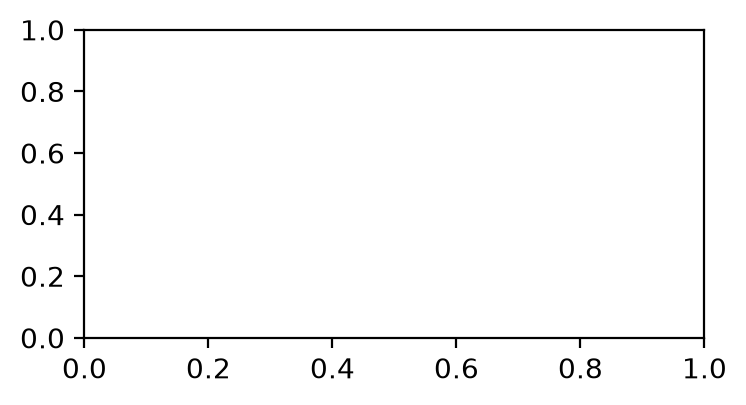

In [79]:

fig,ax=plt.subplots(dpi=200,figsize=(4,2));
ax.errorbar(datetimevbi[177+50:177+110],ysp0,yerr=ysperr0,color='#CC6677')
ax.errorbar(datetimevbi[177+50:177+110],ysp1,yerr=ysperr1,color='green')
ax.errorbar(datetimevbi[177+50:177+110],ysp2,yerr=ysperr2,color='blue')

ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S')) ##Display format - update here to change
plt.xticks(rotation=45) ##Adjust angle and horizontal align right

ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())
ax.grid()

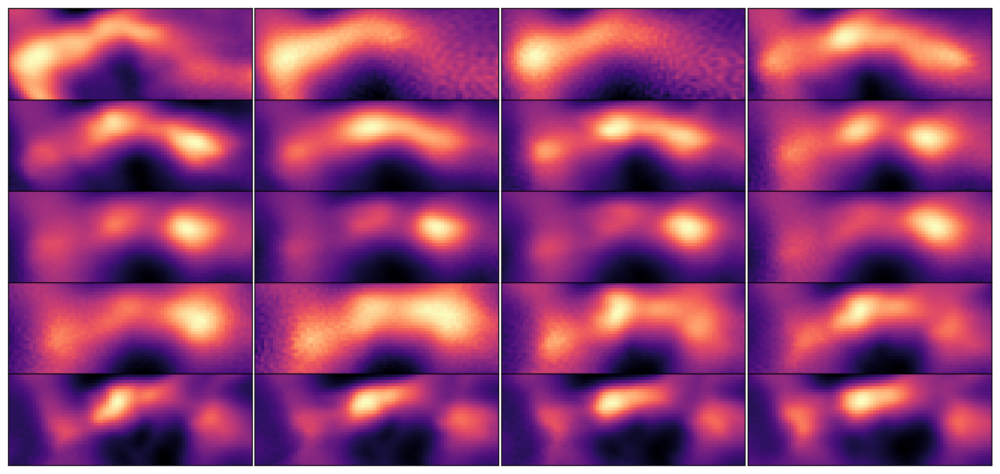

In [63]:
slices2=np.arange(50,110,3)

fig,ax=plt.subplots(5,4,dpi=200,figsize=(15,7))
for i in range(len(slices2)):
    sel = destretch[0].data[slices2[i],2125:2155,2110:2190]
    ax.flatten()[i].set_xticks([])
    ax.flatten()[i].set_yticks([])
    ax.flatten()[i].imshow(sel,cmap='magma')
fig.subplots_adjust(wspace=0, hspace=0)

In [64]:
from scipy.ndimage import gaussian_filter


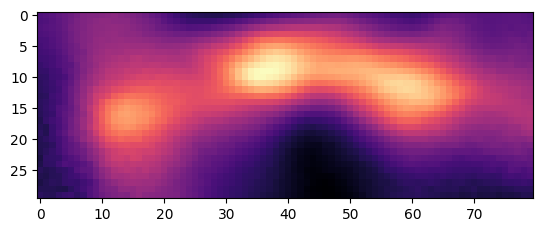

In [65]:
sel=destretch[0].data[slices2[6],2125:2155,2110:2190]
plt.imshow(sel,cmap='magma')


In [66]:
onlytimevbi[180+slices2[6]]
friedvbi[180+slices2[6]]

3.7894907508139806

In [67]:
x1=np.arange(8,75,1)
y1=[]
for i in x1:
    y1.append(np.where(sel[:,i]==np.max(sel[:,i]))[0][0])

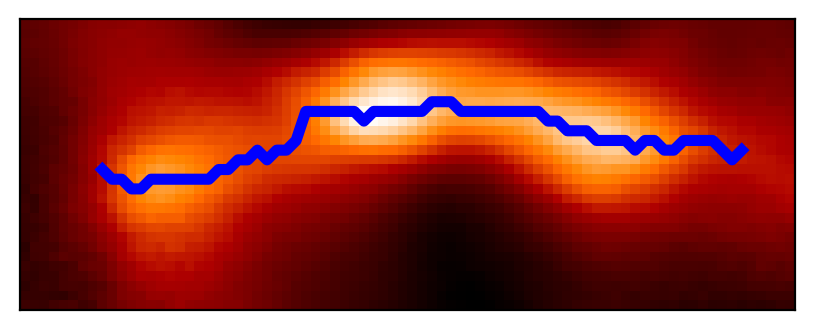

In [68]:
fig,ax=plt.subplots(dpi=200,figsize=(5,2))
ax.imshow(sel,cmap='sdoaia304')
ax.plot(x1,y1,color='blue',linewidth=4)
ax.set_xticks([])
ax.set_yticks([])

textstr = onlytimevbi[180+slices2[6]]+' UT\n'+str(round(friedvbi[180+slices2[6]],2))+' cm'

# Add text with transparent background
# ax.text(0.7, 0.1, textstr, 
#         fontsize=12, 
#     bbox=dict(facecolor='white', alpha=0.5, edgecolor='gray', boxstyle='round,pad=0.5'),transform=ax.transAxes)

In [69]:
#distance between peaks

In [70]:
x1

array([ 8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24,
       25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41,
       42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58,
       59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74])

In [71]:
y1

[np.int64(15),
 np.int64(16),
 np.int64(16),
 np.int64(17),
 np.int64(17),
 np.int64(16),
 np.int64(16),
 np.int64(16),
 np.int64(16),
 np.int64(16),
 np.int64(16),
 np.int64(16),
 np.int64(15),
 np.int64(15),
 np.int64(14),
 np.int64(14),
 np.int64(13),
 np.int64(14),
 np.int64(13),
 np.int64(13),
 np.int64(12),
 np.int64(9),
 np.int64(9),
 np.int64(9),
 np.int64(9),
 np.int64(9),
 np.int64(9),
 np.int64(10),
 np.int64(9),
 np.int64(9),
 np.int64(9),
 np.int64(9),
 np.int64(9),
 np.int64(9),
 np.int64(8),
 np.int64(8),
 np.int64(8),
 np.int64(9),
 np.int64(9),
 np.int64(9),
 np.int64(9),
 np.int64(9),
 np.int64(9),
 np.int64(9),
 np.int64(9),
 np.int64(9),
 np.int64(10),
 np.int64(10),
 np.int64(11),
 np.int64(11),
 np.int64(11),
 np.int64(12),
 np.int64(12),
 np.int64(12),
 np.int64(12),
 np.int64(13),
 np.int64(12),
 np.int64(12),
 np.int64(13),
 np.int64(13),
 np.int64(12),
 np.int64(12),
 np.int64(12),
 np.int64(12),
 np.int64(13),
 np.int64(14),
 np.int64(13)]

In [72]:
sel[y,x]

IndexError: arrays used as indices must be of integer (or boolean) type

In [73]:
coords = np.vstack((y1, x1))

# sample intensities
profile=[]
for i in range(len(x1)):
    profile.append(sel[y1[i],x1[i]])

fwhm1: 165.0077768006697 km
fwhm2: 132.41228797238543 km
fwhm3: 176.13379421046014 km


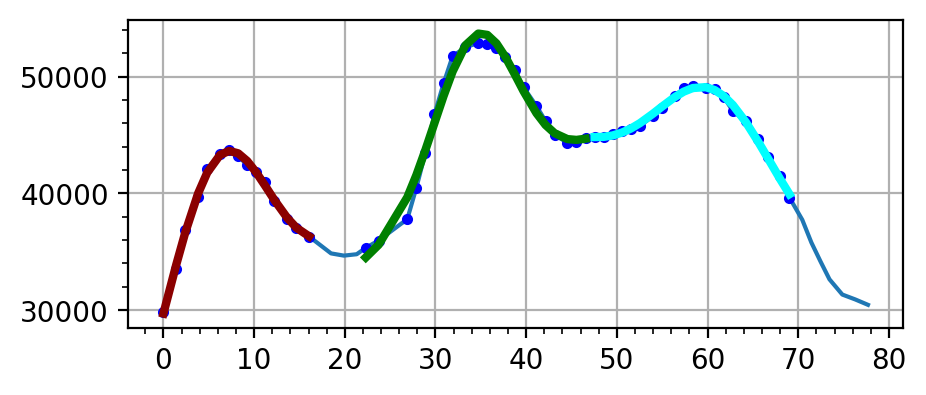

In [74]:


# distance along curve
ds = np.sqrt(np.diff(x1)**2 + np.diff(y1)**2)
s = np.insert(np.cumsum(ds), 0, 0)

# plot
fig,ax=plt.subplots(dpi=200,figsize=(5,2))
ax.plot(s, profile)
# plt.xlabel("Distance along curve (pixels)")
# plt.ylabel("Intensity")
# plt.title("Intensity profile along curve")
# plt.axvline(7)
# plt.axvline(34)
# plt.axvline(58)
# plt.axvline(0,linestyle='-.')
# plt.axvline(20,linestyle='-.')
# plt.axvline(45,linestyle='-.')
# plt.axvline(69,linestyle='-.')

# x = positions
x = s[0:15]
y = profile[0:15]

# Initial guesses
initial_guess = [np.max(y)-np.min(y), np.mean(x), 10, 0, np.min(y)]

params, cov = curve_fit(gaussian_linear, x, y, p0=initial_guess)

A, mu, sigma, B, C = params
print("fwhm1:", sigma*2.3548*0.017*727,'km')

# Plot
ax.plot(x, y, 'b.', label='Data')
ax.plot(x, gaussian_linear(x, *params), '-', color='darkred',linewidth=3, label='Fit')


# x = positions
x = s[19:40]
y = profile[19:40]

# Initial guesses
initial_guess = [np.max(y)-np.min(y), np.mean(x), 10, 0, np.min(y)]

params, cov = curve_fit(gaussian_linear, x, y, p0=initial_guess)

A, mu, sigma, B, C = params
print("fwhm2:", sigma*2.3548*0.017*727,'km')

# Plot
ax.plot(x, y, 'b.', label='Data')
ax.plot(x, gaussian_linear(x, *params), '-', color='green',linewidth=3,label='Fit')

# x = positions
x = s[40:60]
y = profile[40:60]

# Initial guesses
initial_guess = [np.max(y)-np.min(y), np.mean(x), 10, 0, np.min(y)]

params, cov = curve_fit(gaussian_linear, x, y, p0=initial_guess)

A, mu, sigma, B, C = params
print("fwhm3:", sigma*2.3548*0.017*727,'km')

# Plot
ax.plot(x, y, 'b.', label='Data')
ax.plot(x, gaussian_linear(x, *params), '-', color='cyan',linewidth=3, label='Fit')
ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())
ax.grid()




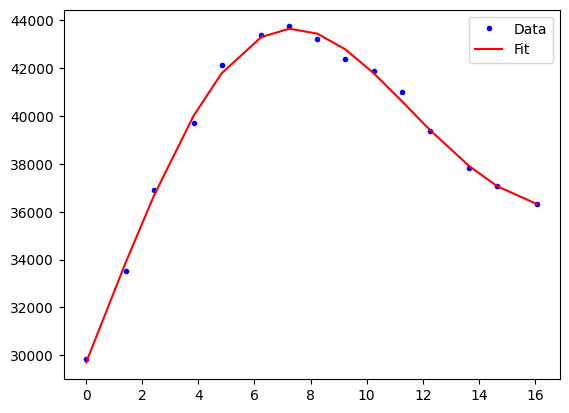

Amplitude: 19652.10236810636
Center: 5.834287453609578
Sigma: 5.669791043915392
fwhm: 13.351223950211965
width: 165.0077768006697
linear slope: 892.3299317777596
Offset: 18128.90634484098


In [75]:
from scipy.optimize import curve_fit

# Gaussian + linear background
def gaussian_linear(x, A, mu, sigma, B, C):
    return A * np.exp(-(x - mu)**2 / (2 * sigma**2)) + B*x + C

# x = positions
x = s[0:15]
y = profile[0:15]

# Initial guesses
initial_guess = [np.max(y)-np.min(y), np.mean(x), 10, 0, np.min(y)]

params, cov = curve_fit(gaussian_linear, x, y, p0=initial_guess)

A, mu, sigma, B, C = params

# Plot
plt.plot(x, y, 'b.', label='Data')
plt.plot(x, gaussian_linear(x, *params), 'r-', label='Fit')
plt.legend()
plt.show()

print("Amplitude:", A)
print("Center:", mu)
print("Sigma:", sigma)
print("fwhm:", sigma*2.3548)
print("width:",np.abs(sigma)*2.3548*0.017*727)
print("linear slope:", B)
print("Offset:", C)

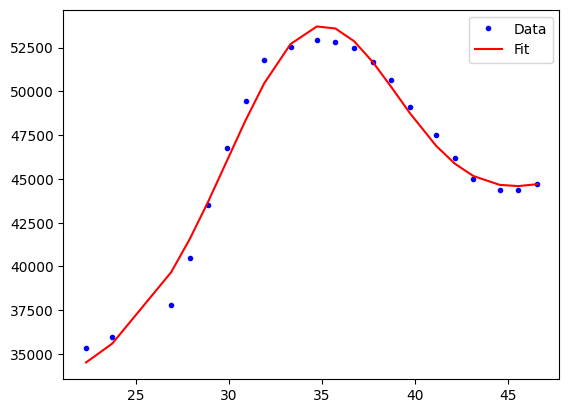

Amplitude: 14425.733081694785
Center: 34.43446422087808
Sigma: 4.5497855859065774
fwhm: 10.713835097692808
width: 132.41228797238543
linear slope: 420.12187165785764
Offset: 24724.73362140891


In [76]:
from scipy.optimize import curve_fit

# Gaussian + linear background
def gaussian_linear(x, A, mu, sigma, B, C):
    return A * np.exp(-(x - mu)**2 / (2 * sigma**2)) + B*x + C

# x = positions
x = s[19:40]
y = profile[19:40]

# Initial guesses
initial_guess = [np.max(y)-np.min(y), np.mean(x), 10, 0, np.min(y)]

params, cov = curve_fit(gaussian_linear, x, y, p0=initial_guess)

A, mu, sigma, B, C = params

# Plot
plt.plot(x, y, 'b.', label='Data')
plt.plot(x, gaussian_linear(x, *params), 'r-', label='Fit')
plt.legend()
plt.show()

print("Amplitude:", A)
print("Center:", mu)
print("Sigma:", sigma)
print("fwhm:", sigma*2.3548)
print("width:",np.abs(sigma)*2.3548*0.017*727)
print("linear slope:", B)
print("Offset:", C)

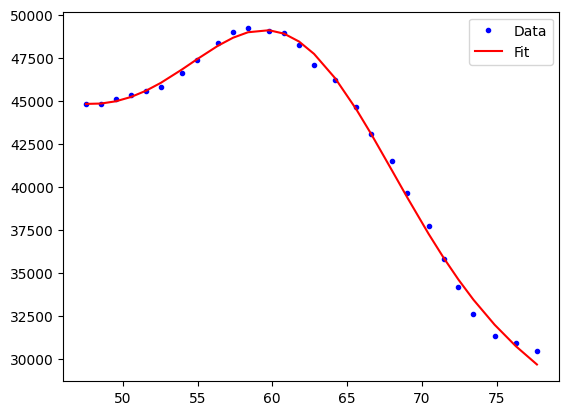

Amplitude: 11872.408056748038
Center: 61.35662300599237
Sigma: 6.74219220077657
fwhm: 15.876514194388667
width: 196.21783892844954
linear slope: -475.0874354476309
Offset: 65950.97188410995


In [77]:
from scipy.optimize import curve_fit

# Gaussian + linear background
def gaussian_linear(x, A, mu, sigma, B, C):
    return A * np.exp(-(x - mu)**2 / (2 * sigma**2)) + B*x + C

# x = positions
x = s[40:69]
y = profile[40:69]

# Initial guesses
initial_guess = [np.max(y)-np.min(y), np.mean(x), 10, 0, np.min(y)]

params, cov = curve_fit(gaussian_linear, x, y, p0=initial_guess)

A, mu, sigma, B, C = params

# Plot
plt.plot(x, y, 'b.', label='Data')
plt.plot(x, gaussian_linear(x, *params), 'r-', label='Fit')
plt.legend()
plt.show()

print("Amplitude:", A)
print("Center:", mu)
print("Sigma:", sigma)
print("fwhm:", sigma*2.3548)
print("width:",np.abs(sigma)*2.3548*0.017*727)
print("linear slope:", B)
print("Offset:", C)

In [78]:
sel=destretch[0].data[slices2[48],2125:2155,2110:2190]
plt.imshow(sel,cmap='magma')

IndexError: index 48 is out of bounds for axis 0 with size 20

In [79]:
x=np.arange(8,80,1)
y=[]
for i in x:
    y.append(np.where(sel[:,i]==np.max(sel[:,i]))[0][0])

In [80]:
sel=destretch[0].data[slices2[48],2125:2155,2110:2190]
plt.imshow(destretch[0].data[slices2[48],2125:2155,2110:2190],cmap='magma')
plt.scatter(x,y)

IndexError: index 48 is out of bounds for axis 0 with size 20

In [81]:
coords = np.vstack((y, x))

# sample intensities
profile = map_coordinates(sel, coords, order=1)

# distance along curve
ds = np.sqrt(np.diff(x)**2 + np.diff(y)**2)
s = np.insert(np.cumsum(ds), 0, 0)

# plot
plt.plot(s, profile)
plt.xlabel("Distance along curve (pixels)")
plt.ylabel("Intensity")
plt.title("Intensity profile along curve")
# plt.axvline(7)
# plt.axvline(34)
# plt.axvline(58)
# plt.axvline(0,linestyle='-.')
# plt.axvline(21,linestyle='-.')
# plt.axvline(45,linestyle='-.')
# plt.axvline(69,linestyle='-.')
plt.show()

NameError: name 'map_coordinates' is not defined

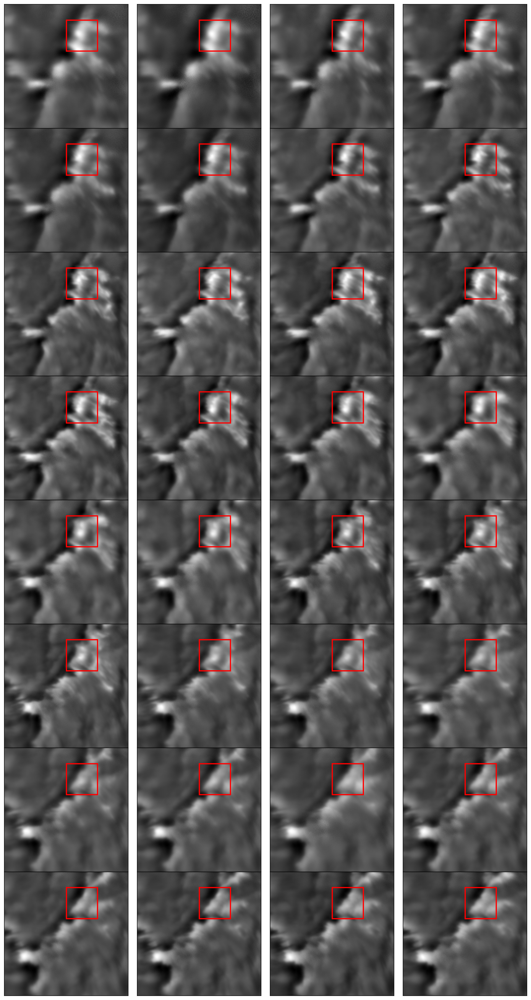

In [81]:
slices2=np.arange(90,122,1)

fig,ax=plt.subplots(8,4,dpi=200,figsize=(16,30))
for i in range(len(slices2)):
    sel = destretch[0].data[slices2[i],2270:2470,1900:2100]
    ax.flatten()[i].set_xticks([])
    ax.flatten()[i].set_yticks([])

    rect = patches.Rectangle((100, 25), 50, 50, 
                         linewidth=2, 
                         edgecolor='r', 
                         facecolor='none')
    ax.flatten()[i].add_patch(rect)


    
    ax.flatten()[i].imshow(sel,cmap='grey')
fig.subplots_adjust(wspace=0, hspace=0)

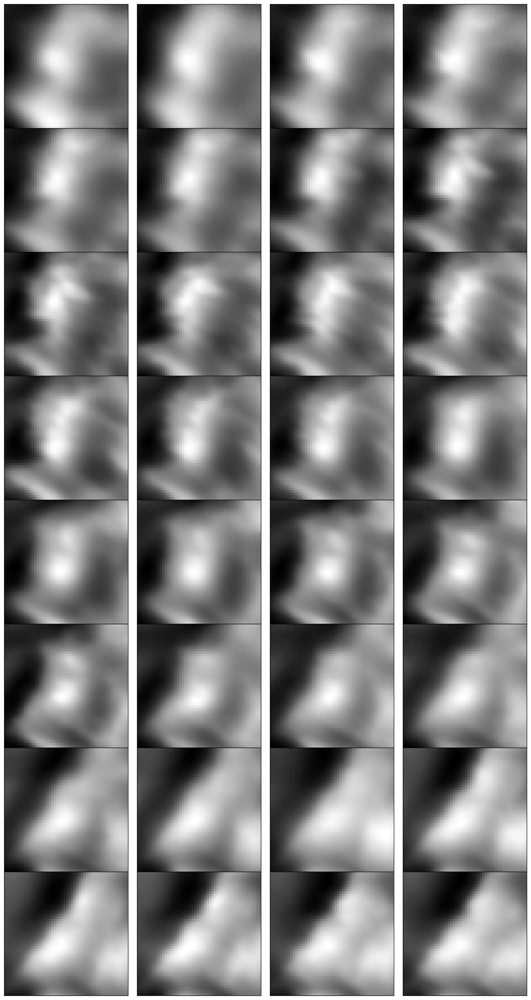

In [82]:
fig,ax=plt.subplots(8,4,dpi=200,figsize=(16,30))
for i in range(len(slices2)):
    sel = destretch[0].data[slices2[i],2295:2345,2000:2050]
    ax.flatten()[i].set_xticks([])
    ax.flatten()[i].set_yticks([])


    
    ax.flatten()[i].imshow(sel,cmap='grey')
fig.subplots_adjust(wspace=0, hspace=0)

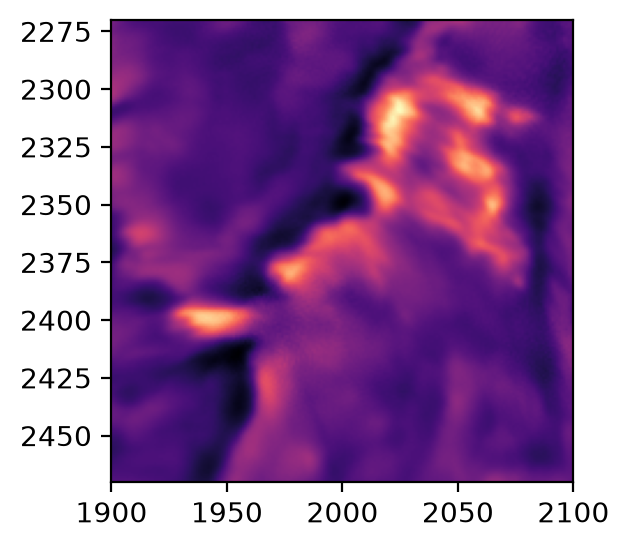

In [83]:
sel = destretch[0].data[slices2[10]]
fig,ax=plt.subplots(dpi=200,figsize=(3,3))
ax.set_xlim([1900,2100])
ax.set_ylim([2470,2270])
ax.imshow(sel,cmap='magma')

In [84]:
onlytimevbi[180+slices2[10]]
friedvbi[180+slices2[10]]

6.8980319328632165

[]

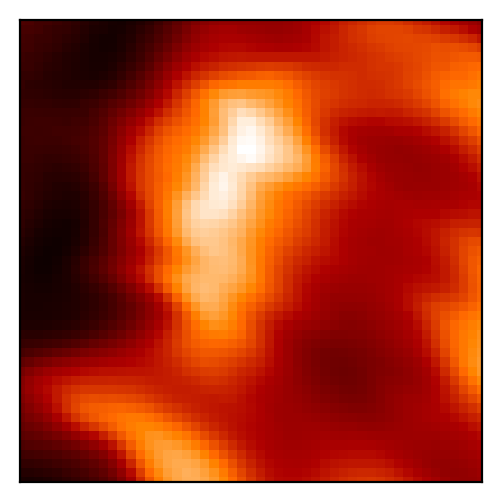

In [85]:
sel = destretch[0].data[slices2[10]]
fig,ax=plt.subplots(dpi=200,figsize=(3,3))

ax.set_xlim([2000,2050])
ax.set_ylim([2345,2295])
ax.imshow(sel,cmap='sdoaia304')
ax.set_xticks([])
ax.set_yticks([])



[]

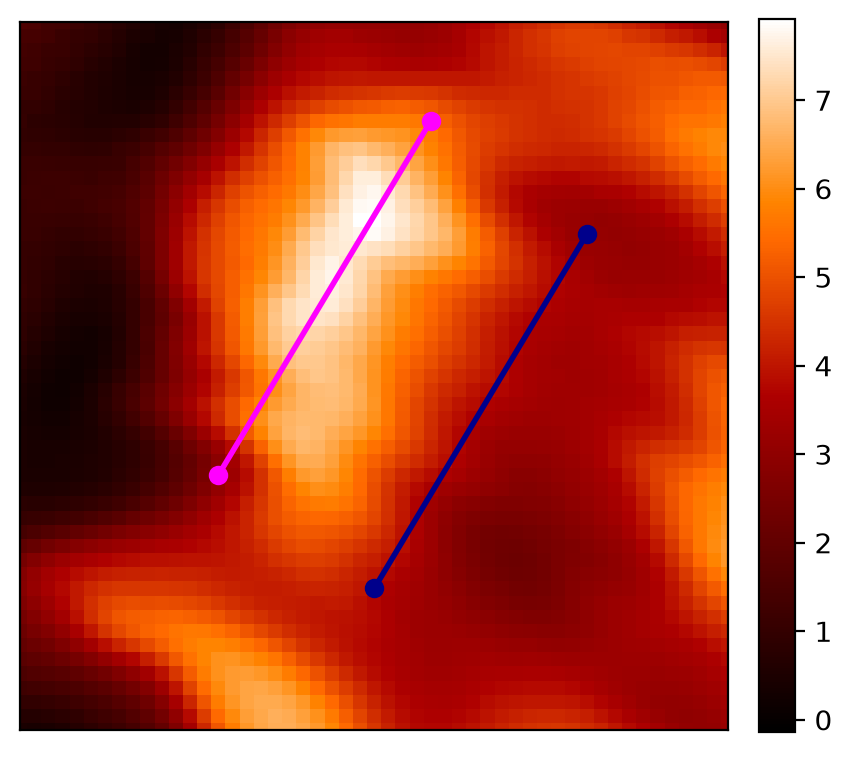

In [86]:
spatial_samp = 0.017

# two points
x0, y0 = 2025,2335
x1, y1 = 2040,2310

x2, y2 = 2014,2327
x3, y3 = 2029,2302

profile = profile_line(sel,[y0,x0],[y1,x1])  # note: row,col order
profile2 = profile_line(sel,[y2,x2],[y3,x3])  # note: row,col order


xdirection = np.arange(len(profile))*spatial_samp
xdirection2 = np.arange(len(profile2))*spatial_samp



fig,ax=plt.subplots(dpi=200,figsize=(5,5))
img=ax.imshow(sel/1e4,cmap='sdoaia304')
ax.set_xlim([2000,2050])
ax.set_ylim([2345,2295])
ax.plot([x0, x1], [y0, y1], 'o-',color='darkblue',linewidth=2)
ax.plot([x2, x3], [y2, y3], 'o-',color='magenta',linewidth=2)
fig.colorbar(img,fraction=0.046, pad=0.04)
ax.set_xticks([])
ax.set_yticks([])

In [87]:
def convert_decimal_to_hms(decimal_hours):
    # Calculate total seconds
    total_seconds = int(decimal_hours * 3600)
    
    # Calculate hours, minutes, seconds
    hours = total_seconds // 3600
    minutes = (total_seconds % 3600) // 60
    seconds = total_seconds % 60
    
    return hours, minutes, seconds

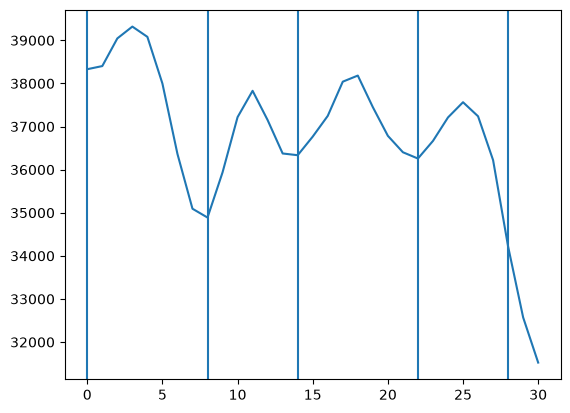

In [88]:

plt.plot(profile)
plt.axvline(0)
plt.axvline(8)
plt.axvline(14)
plt.axvline(22)
plt.axvline(28)

inds = [0,8,14,22,28]

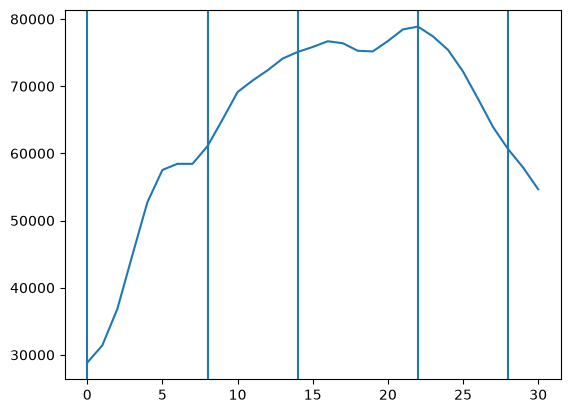

In [89]:

plt.plot(profile2)
plt.axvline(0)
plt.axvline(8)
plt.axvline(14)
plt.axvline(22)
plt.axvline(28)

inds = [0,8,14,22,28]

fwhm2: -53.44531848237902 km
err2: 3.5414335184021826 km
fwhm2: -38.78793022761089 km
err2: 2.346940743535397 km
fwhm2: -41.35331998323542 km
err2: 3.039421815449471 km
fwhm2: -61.82579748890644 km
err2: 6.248545553393769 km


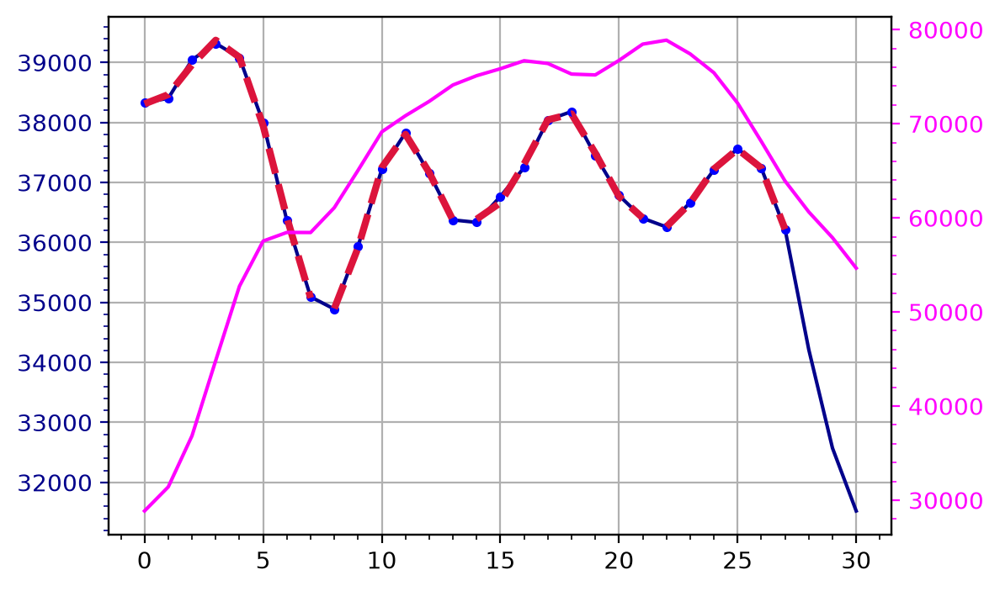

In [92]:

# plot
fig,ax=plt.subplots(dpi=200,figsize=(6,4))
ax.plot(xdirection/0.017, profile,color='darkblue')
ax.yaxis.set_minor_locator(AutoMinorLocator())

ax.tick_params(axis='y', colors='darkblue',which='both')

ax2=ax.twinx()
ax2.plot(xdirection2/0.017, profile2,color='magenta')
ax2.yaxis.set_minor_locator(AutoMinorLocator())
ax2.tick_params(axis='y', colors='magenta',which='both')

# x = positions
x = xdirection[inds[0]:inds[1]]/0.017
y = profile[inds[0]:inds[1]]

# Initial guesses
initial_guess = [np.max(y)-np.min(y), np.mean(x), 10, 0, np.min(y)]

params, cov = curve_fit(gaussian_linear, x, y, p0=initial_guess)
err = np.sqrt(np.diag(cov))[2]

A, mu, sigma, B, C = params
print("fwhm2:", sigma*2.3548*0.017*727,'km')
print("err2:", err*2.3548*0.017*727,'km')

# Plot
ax.plot(x, y, 'b.', label='Data')
ax.plot(x, gaussian_linear(x, *params), '--', color='crimson',linewidth=3, label='Fit')

# x = positions
x = xdirection[inds[1]:inds[2]]/0.017
y = profile[inds[1]:inds[2]]

# Initial guesses
initial_guess = [np.max(y)-np.min(y), np.mean(x), 10, 0, np.min(y)]

params, cov = curve_fit(gaussian_linear, x, y, p0=initial_guess)
err = np.sqrt(np.diag(cov))[2]

A, mu, sigma, B, C = params
print("fwhm2:", sigma*2.3548*0.017*727,'km')
print("err2:", err*2.3548*0.017*727,'km')

# Plot
ax.plot(x, y, 'b.', label='Data')
ax.plot(x, gaussian_linear(x, *params), '--', color='crimson',linewidth=3, label='Fit')

# x = positions
x = xdirection[inds[2]:inds[3]]/0.017
y = profile[inds[2]:inds[3]]

# Initial guesses
initial_guess = [np.max(y)-np.min(y), np.mean(x), 10, 0, np.min(y)]

params, cov = curve_fit(gaussian_linear, x, y, p0=initial_guess)
err = np.sqrt(np.diag(cov))[2]

A, mu, sigma, B, C = params
print("fwhm2:", sigma*2.3548*0.017*727,'km')
print("err2:", err*2.3548*0.017*727,'km')

# Plot
ax.plot(x, y, 'b.', label='Data')
ax.plot(x, gaussian_linear(x, *params), '--', color='crimson',linewidth=3, label='Fit')

# x = positions
x = xdirection[inds[3]:inds[4]]/0.017
y = profile[inds[3]:inds[4]]

# Initial guesses
initial_guess = [np.max(y)-np.min(y), np.mean(x), 10, 0, np.min(y)]

params, cov = curve_fit(gaussian_linear, x, y, p0=initial_guess)
err = np.sqrt(np.diag(cov))[2]

A, mu, sigma, B, C = params
print("fwhm2:", sigma*2.3548*0.017*727,'km')
print("err2:", err*2.3548*0.017*727,'km')

# Plot
ax.plot(x, y, 'b.', label='Data')
ax.plot(x, gaussian_linear(x, *params), '--', color='crimson',linewidth=3, label='Fit')


ax.xaxis.set_minor_locator(AutoMinorLocator())

#ax.set_ylim([34000,40000])
ax.grid()


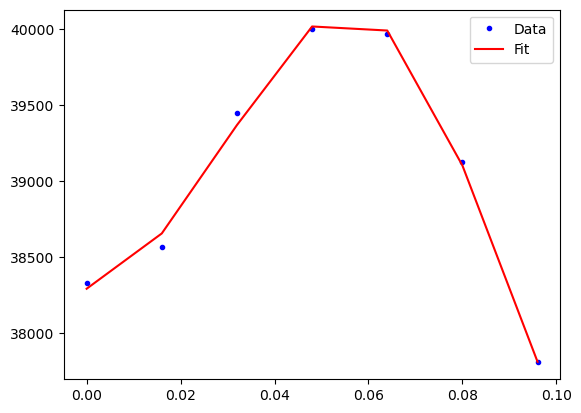

Amplitude: 3176.5377813145574
Center: 0.06027505097556544
Sigma: 0.029296931884647475
fwhm: 0.06898841520196787
width: 50.154577851830645
linear slope: -16746.241389152798
Offset: 37910.80026728517


In [396]:
from scipy.optimize import curve_fit

# Gaussian + linear background
def gaussian_linear(x, A, mu, sigma, B, C):
    return A * np.exp(-(x - mu)**2 / (2 * sigma**2)) + B*x + C

# x = positions
x = xdirection[inds[0]:inds[1]]
y = profile[inds[0]:inds[1]]

# Initial guesses
initial_guess = [np.max(y)-np.min(y), np.mean(x), 0.01, 0, np.min(y)]

params, cov = curve_fit(gaussian_linear, x, y, p0=initial_guess)

A, mu, sigma, B, C = params

# Plot
plt.plot(x, y, 'b.', label='Data')
plt.plot(x, gaussian_linear(x, *params), 'r-', label='Fit')
plt.legend()
plt.show()

print("Amplitude:", A)
print("Center:", mu)
print("Sigma:", sigma)
print("fwhm:", sigma*2.3548)
print("width:",np.abs(sigma)*2.3548*727)
print("linear slope:", B)
print("Offset:", C)

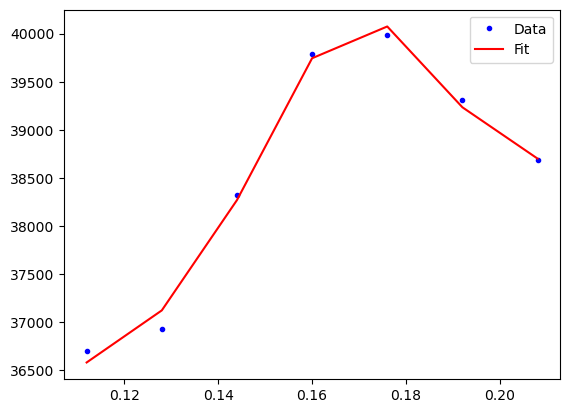

Amplitude: 2472.9775203684744
Center: 0.1681627137200752
Sigma: 0.018882281997465587
fwhm: 0.04446399764763196
width: 32.32532628982843
linear slope: 19614.94817467502
Offset: 34353.6546161909


In [397]:
from scipy.optimize import curve_fit

# Gaussian + linear background
def gaussian_linear(x, A, mu, sigma, B, C):
    return A * np.exp(-(x - mu)**2 / (2 * sigma**2)) + B*x + C

# x = positions
x = xdirection[inds[1]:inds[2]]
y = profile[inds[1]:inds[2]]

# Initial guesses
initial_guess = [np.max(y)-np.min(y), np.mean(x), 0.01, 0, np.min(y)]

params, cov = curve_fit(gaussian_linear, x, y, p0=initial_guess)

A, mu, sigma, B, C = params

# Plot
plt.plot(x, y, 'b.', label='Data')
plt.plot(x, gaussian_linear(x, *params), 'r-', label='Fit')
plt.legend()
plt.show()

print("Amplitude:", A)
print("Center:", mu)
print("Sigma:", sigma)
print("fwhm:", sigma*2.3548)
print("width:",np.abs(sigma)*2.3548*727)
print("linear slope:", B)
print("Offset:", C)

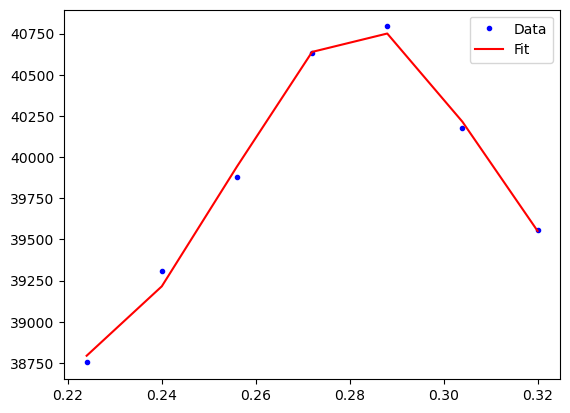

Amplitude: 1988.9620226771024
Center: 0.28136808089914805
Sigma: 0.025441981440688176
fwhm: 0.05991077789653251
width: 43.55513553077914
linear slope: 2986.9433185671733
Offset: 37967.991021129455


In [356]:
from scipy.optimize import curve_fit

# Gaussian + linear background
def gaussian_linear(x, A, mu, sigma, B, C):
    return A * np.exp(-(x - mu)**2 / (2 * sigma**2)) + B*x + C

# x = positions
x = xdirection[inds[2]:inds[3]]
y = profile[inds[2]:inds[3]]

# Initial guesses
initial_guess = [np.max(y)-np.min(y), np.mean(x), 0.01, 0, np.min(y)]

params, cov = curve_fit(gaussian_linear, x, y, p0=initial_guess)

A, mu, sigma, B, C = params

# Plot
plt.plot(x, y, 'b.', label='Data')
plt.plot(x, gaussian_linear(x, *params), 'r-', label='Fit')
plt.legend()
plt.show()

print("Amplitude:", A)
print("Center:", mu)
print("Sigma:", sigma)
print("fwhm:", sigma*2.3548)
print("width:",np.abs(sigma)*2.3548*727)
print("linear slope:", B)
print("Offset:", C)

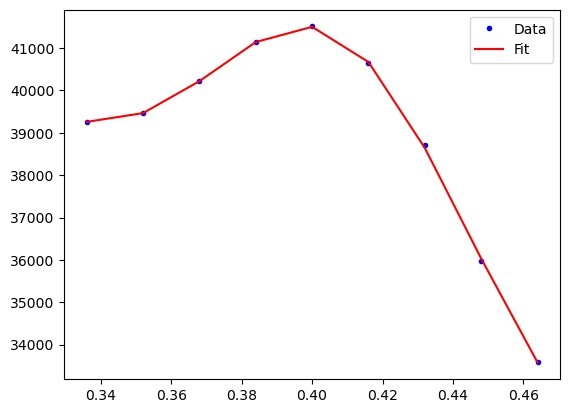

Amplitude: 6627.670507387432
Center: 0.4081726552733211
Sigma: 0.03538735737384587
fwhm: 0.08333014914393226
width: 60.58101842763875
linear slope: -52822.32192044499
Offset: 56178.24928280265


In [357]:
from scipy.optimize import curve_fit

# Gaussian + linear background
def gaussian_linear(x, A, mu, sigma, B, C):
    return A * np.exp(-(x - mu)**2 / (2 * sigma**2)) + B*x + C

# x = positions
x = xdirection[inds[3]:inds[4]]
y = profile[inds[3]:inds[4]]

# Initial guesses
initial_guess = [np.max(y)-np.min(y), np.mean(x), 0.01, 0, np.min(y)]

params, cov = curve_fit(gaussian_linear, x, y, p0=initial_guess)

A, mu, sigma, B, C = params

# Plot
plt.plot(x, y, 'b.', label='Data')
plt.plot(x, gaussian_linear(x, *params), 'r-', label='Fit')
plt.legend()
plt.show()

print("Amplitude:", A)
print("Center:", mu)
print("Sigma:", sigma)
print("fwhm:", sigma*2.3548)
print("width:",np.abs(sigma)*2.3548*727)
print("linear slope:", B)
print("Offset:", C)